# Data generation

In [ ]:
import numpy as np
import scipy
import matplotlib.pyplot as plt
import yaml
import copy

np.set_printoptions(precision=5, suppress=True, linewidth=100)
plt.rcParams['figure.dpi'] = 150

import tenpy
import torch

In [ ]:
# This is how we define the parameters of the Ising chain and find its ground state using imaginary
# time evolution

sim_params_gs = yaml.safe_load("""

simulation_class : GroundStateSearch

model_class :  SpinChain
model_params :
    L : 90
    bc_MPS : finite
    S  : 0.5
    Jx : 0
    Jy : 0
    Jz : -1
    hx : -0.3
    hz : -0

initial_state_params:
    method : lat_product_state
    product_state : [[up], [down]]

algorithm_class: TwoSiteDMRGEngine

algorithm_params:
    trunc_params:
        svd_min: 1.e-8
        chi_max: 64
""")

ground_state_data1 = tenpy.run_simulation(**sim_params_gs)

In [ ]:
#DATA 1 LP
sim_params_spectra = yaml.safe_load("""

simulation_class: SpectralSimulation

operator_t0:
    opname: 'Sy'  
operator_t: 'Sy'

final_time: 12

algorithm_class: TEBDEngine

algorithm_params:
    trunc_params:
        chi_max: 64
    dt : 0.1
    N_steps : 2 
    order: 2

spectral_function_params:
    linear_predict: True
    rel_prediction_time: 0.5
    gaussian_window: True

""")

spectral = tenpy.run_simulation(**sim_params_spectra, simulation_class_kwargs=dict(ground_state_data=ground_state_data1))

In the example above, we defined the parameters of our Ising chain and found its groundstate. 
Afterwards we applied the $S_y$ operator to the middle of the groundstate, representing a perturbation. We then evolve the state in time for 120 time steps to compute the $<\sigma_y(\text{t})\sigma_{y,L/2}>$, then apply linear prediction to the first 120 time steps of the correlator in k-space to extrapolate the rest of the 60 time steps, as can be seen in the Image below

In [ ]:
import matplotlib.pyplot as plt
# Now we define the diff. C matrices:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

mpl.rcParams.update({
    "font.family": "serif",
    "font.serif": ["CMU Serif", "Computer Modern Roman", "DejaVu Serif"],
    "mathtext.fontset": "cm",
    "axes.unicode_minus": False,
    "font.size": 10,        # body
    "axes.labelsize": 11,   # axis labels
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 9,
})

sf20 = spectral20['spectral_function_Sy_Sy']  # Example Dataset Linear Prediction (LP)
sf21 = spectral21['spectral_function_Sy_Sy']  # Example Dataset No Prediction (NP)

# To scale the x-axis in the plot
x = 0.1*np.arange(181)

plt.figure()
# Ising chain parameters
plt.title("J = 1, h$_x$ = 0.6, h$_z$ = 0.5, k = 13")
plt.plot(x, C_k_t_LP11.T[13], label = "Linear prediction")
plt.plot(x, C_k_t_NP11.T[13], label = "Ground Truth")
plt.axvline(x=12, color='gray', linestyle='--', linewidth=1.0, label = "Prediction start")
plt.xlabel(r"$t$")
plt.ylabel(r"Re$(C(k,t))$")
plt.legend()
plt.plot()

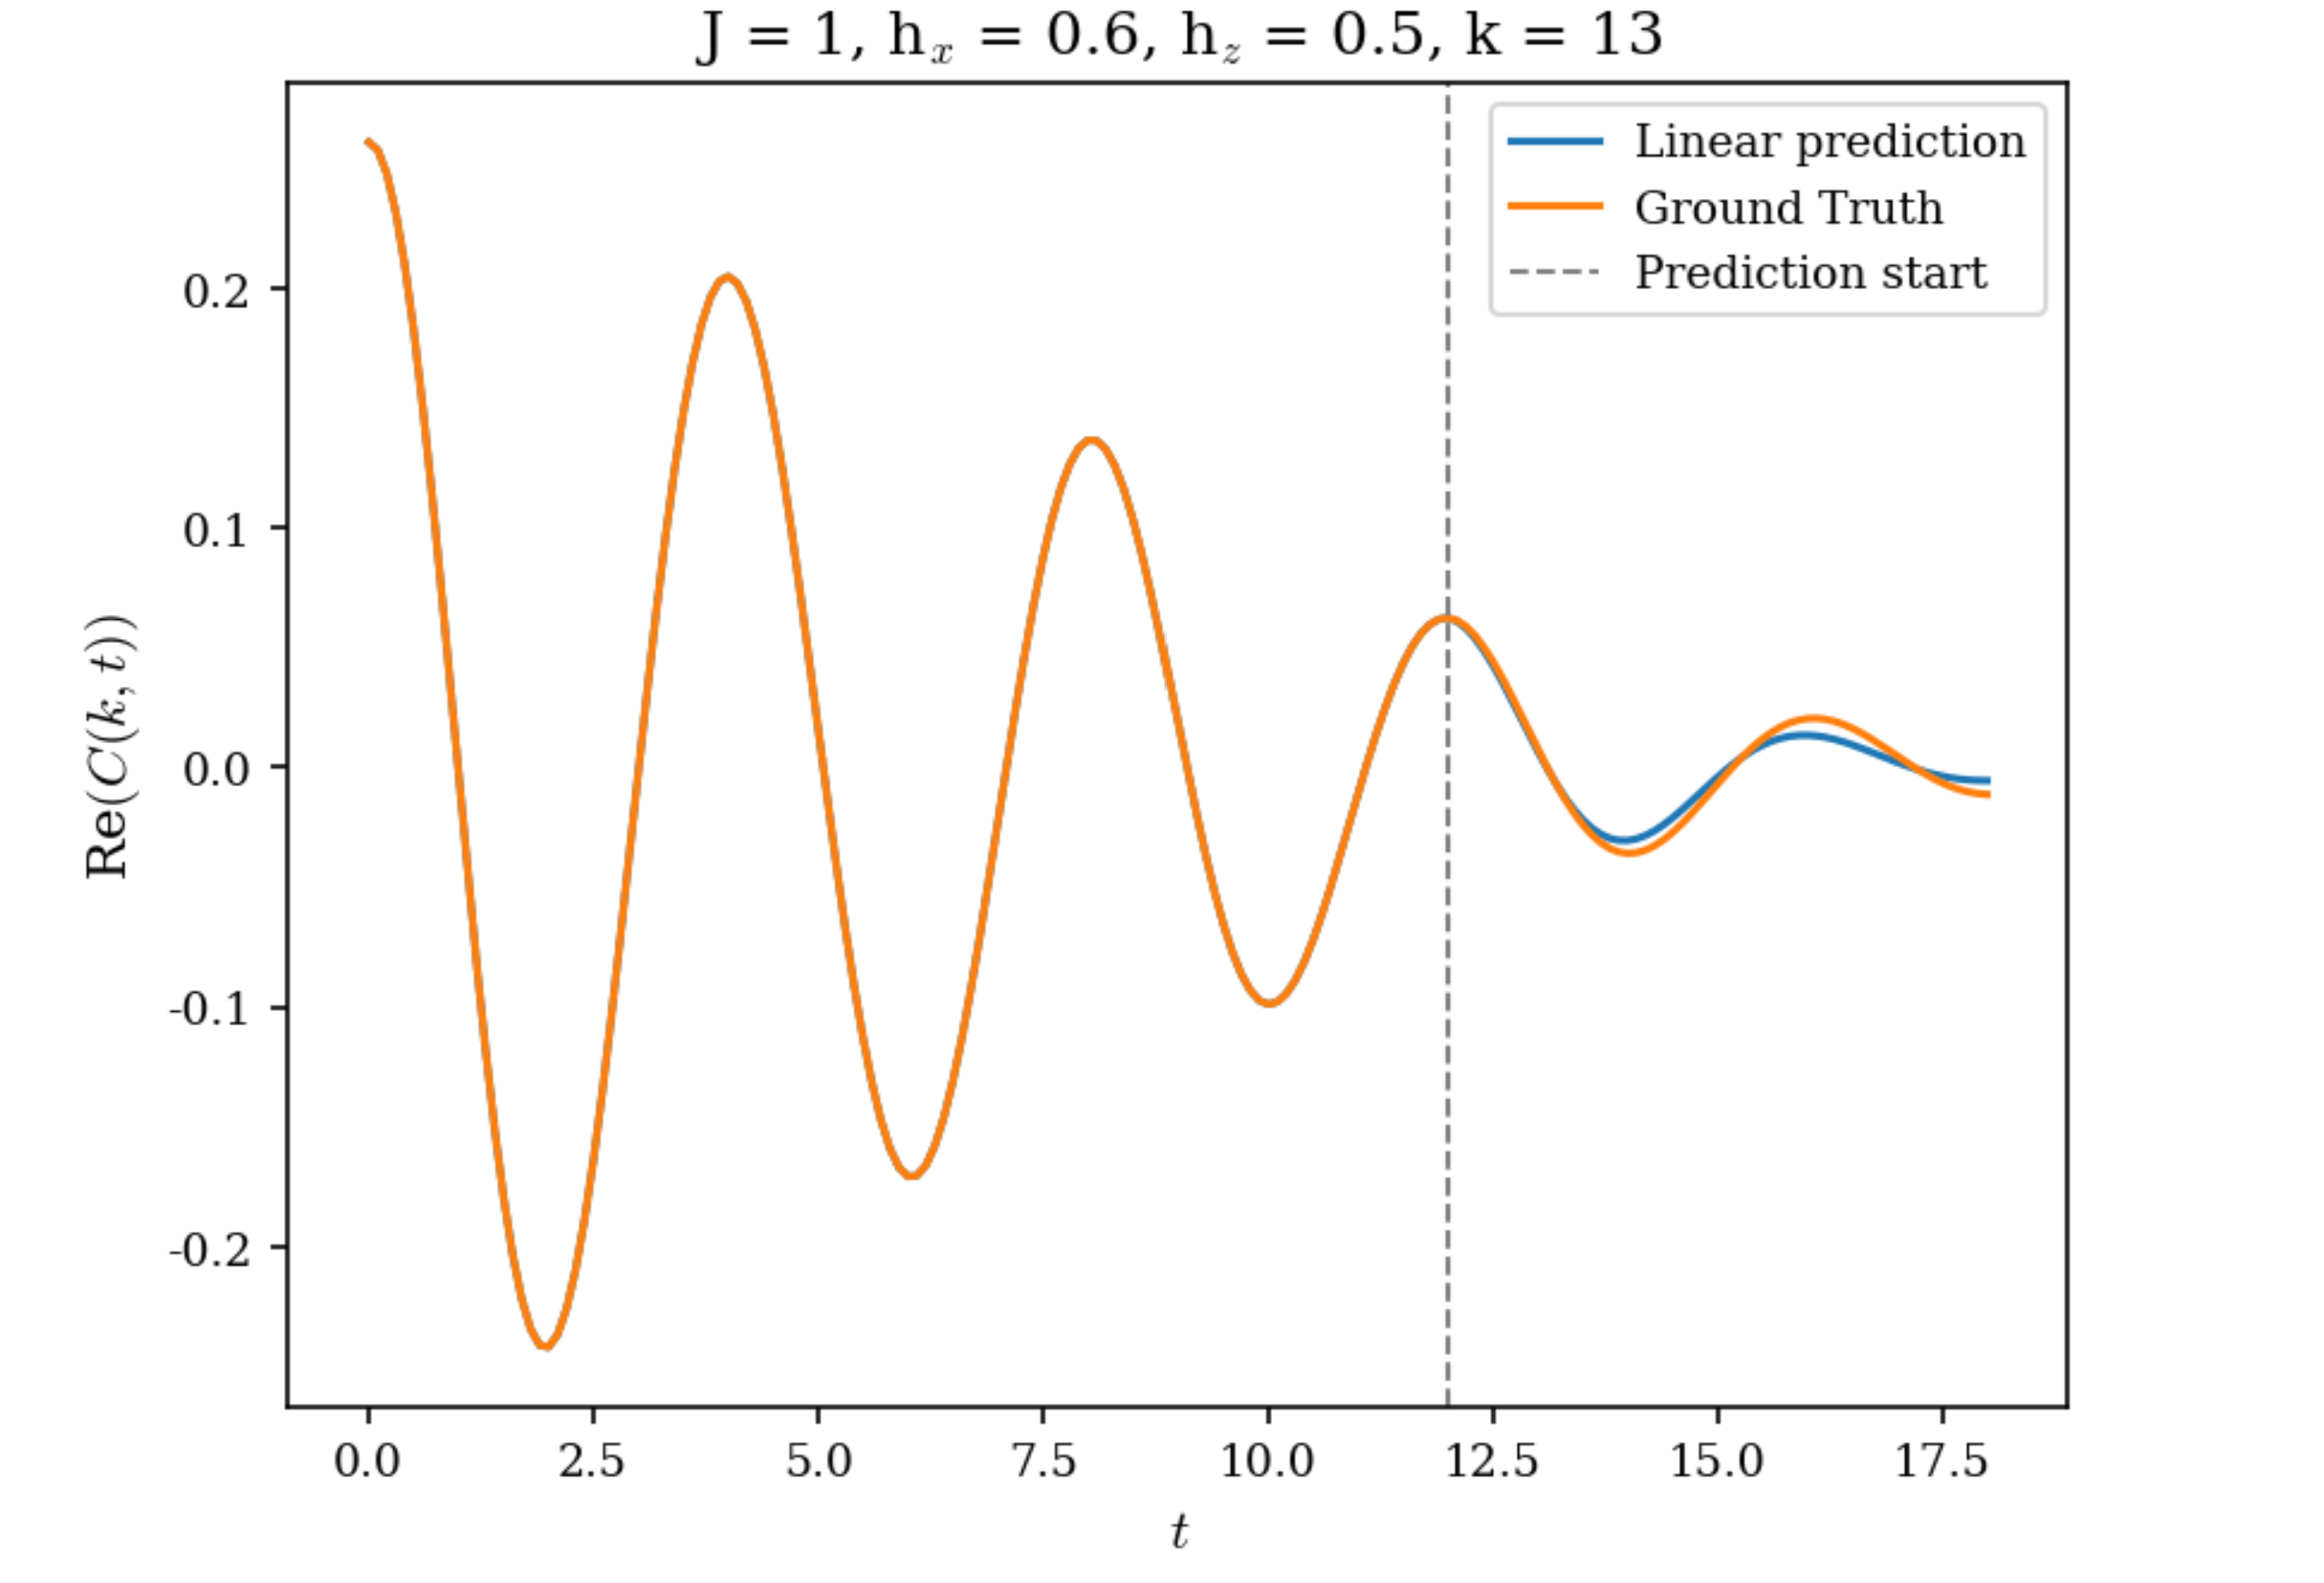

# Perturbation spread in real space (heat map)

In [ ]:
S, T = C_k_t_LP22.T.shape
dt = 0.1  # Δt

print(T)

# inverse discrete FT over k -> real-space correlator, assuming uniform k-grid
Cjt = np.fft.ifft(C_k_t_LP5.T, axis=0).transpose()    # (S, T); real space sites if k-grid matches DFT

plt.figure(figsize=(7.5, 5.6))
extent = [0, S-1, 0, dt*(T-1)]
plt.imshow(np.abs(Cjt), aspect='auto', origin='lower', extent=extent, cmap='viridis')
plt.xlabel("site j")
plt.ylabel("time t")
plt.colorbar(label=r"$|C(j,t)|$")
plt.tight_layout(); plt.show()

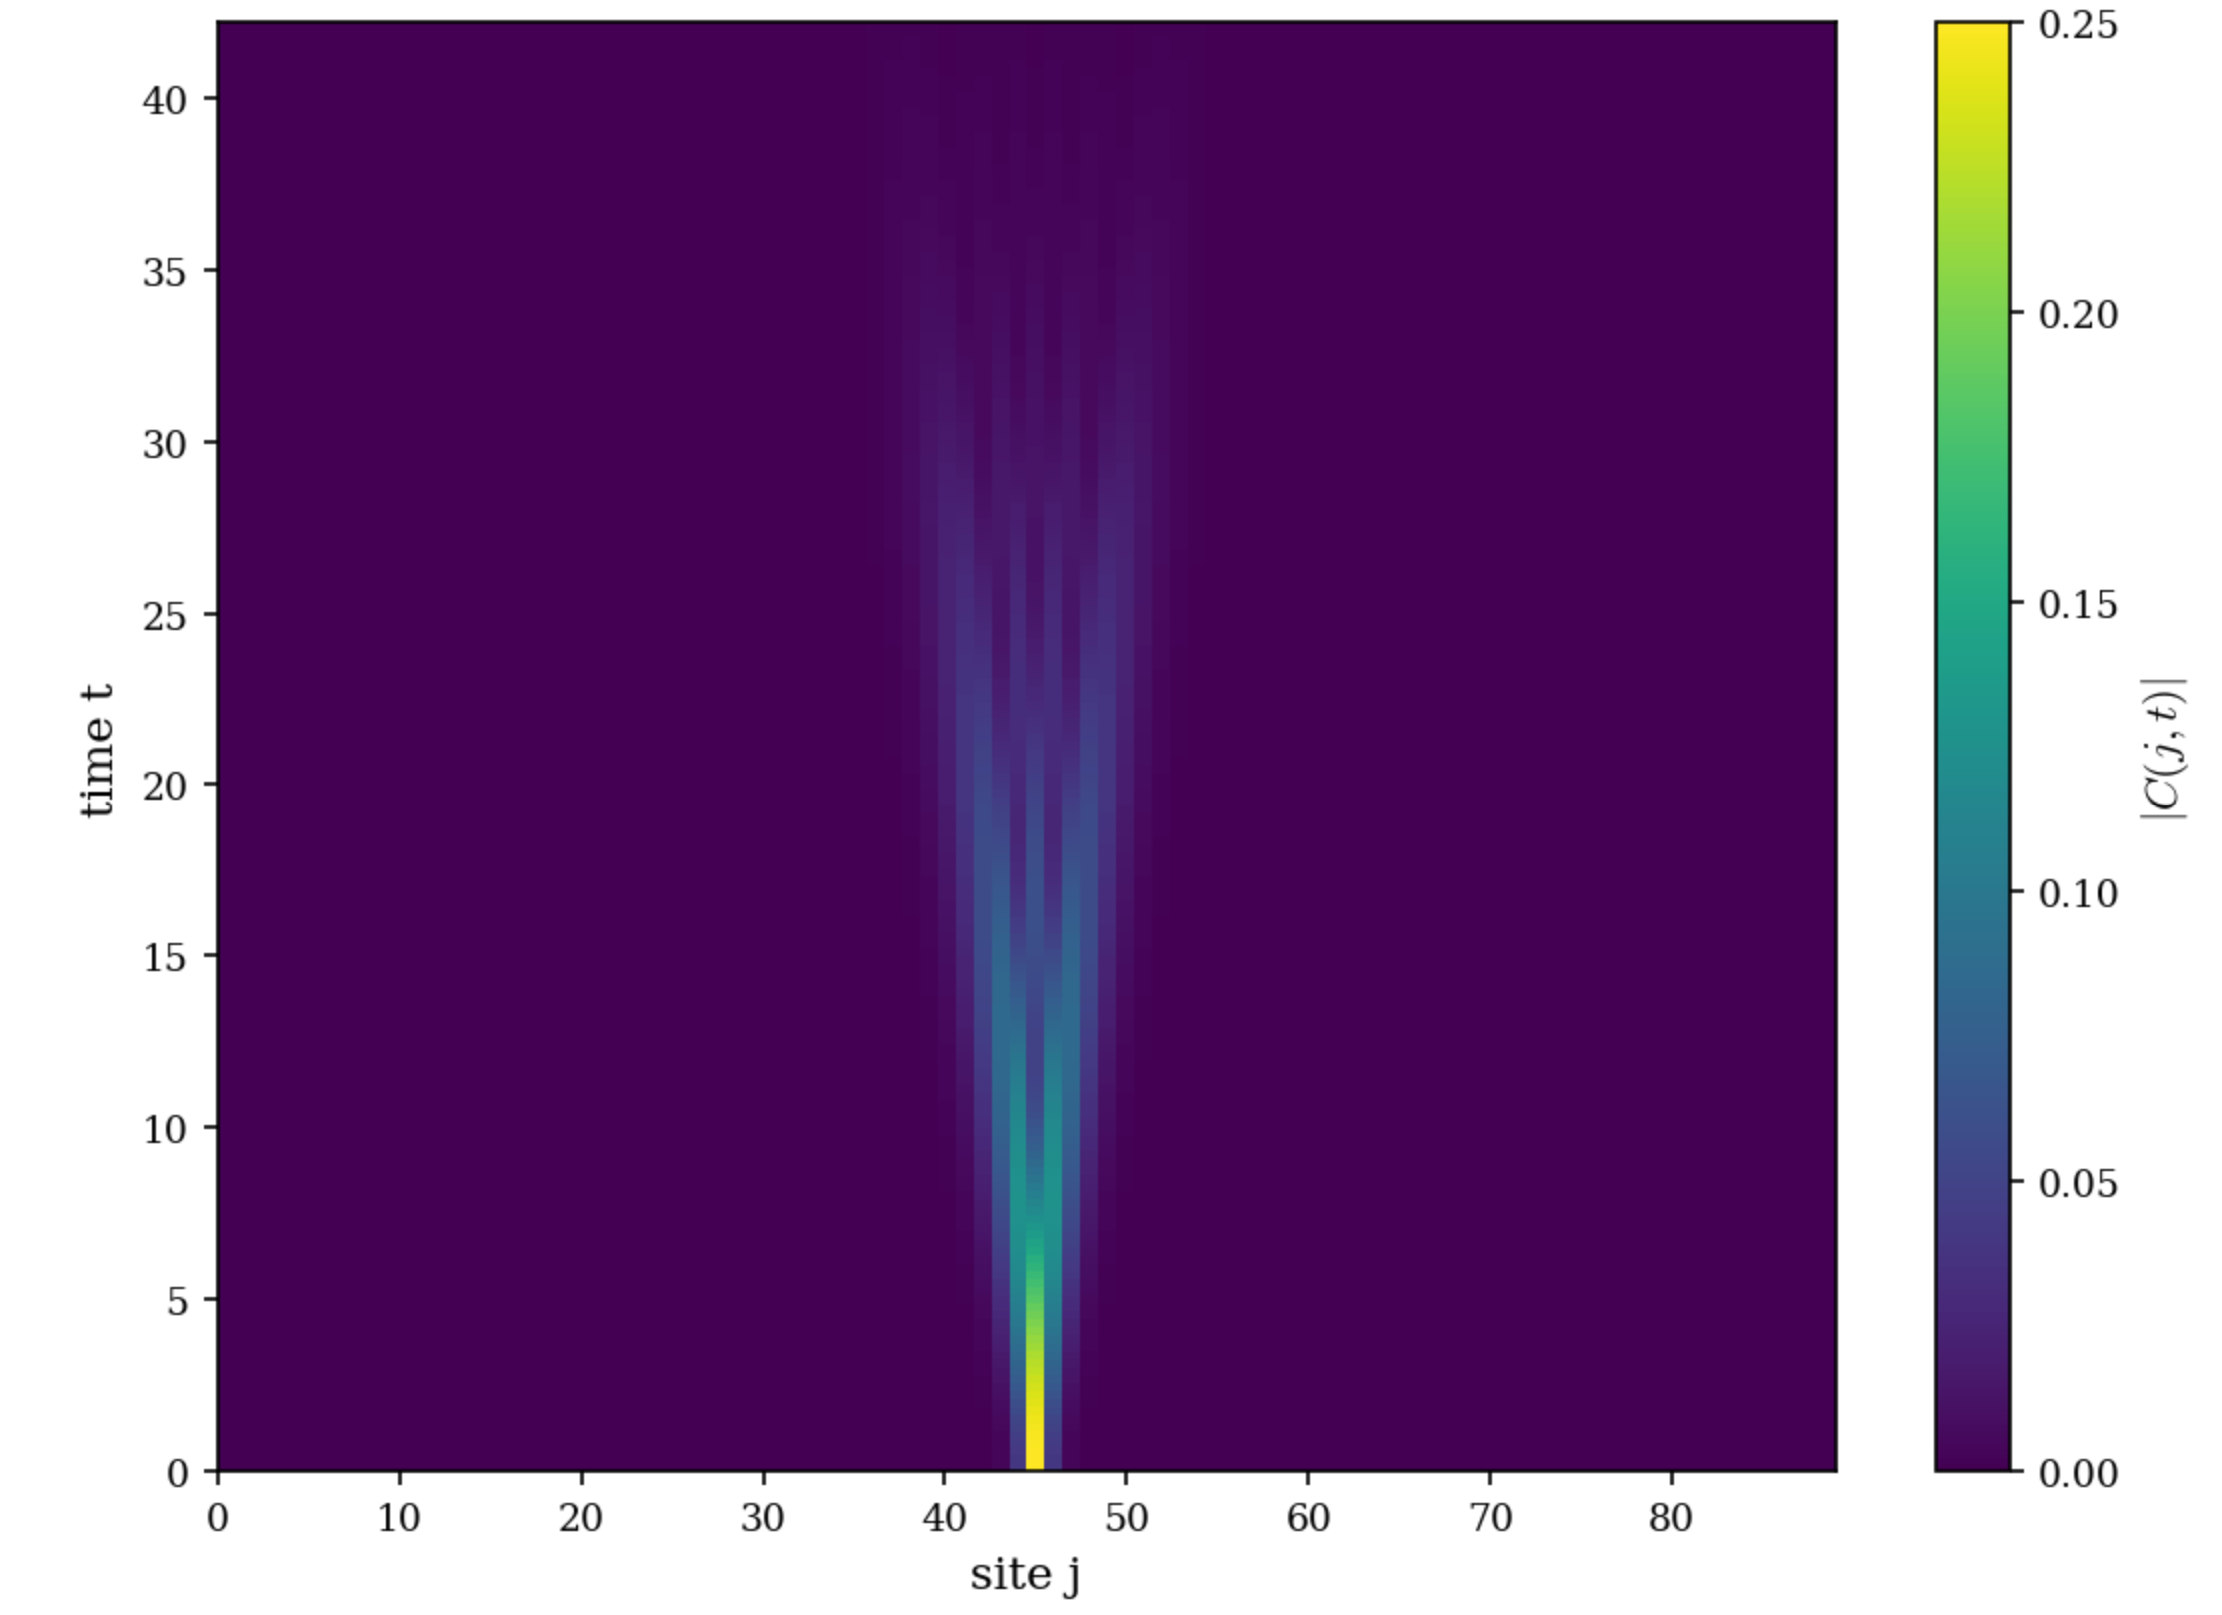

# Dynamic spin factor (exactly solvable Transverse Field Ising Chain (TFIC))

In [ ]:
# Fourier transform function
def fourier_transform_time(a, dt, axis=0):
    # fourier transform in time (ifft convention, then build ω)
    ft_time = np.fft.ifft(a, axis=axis) * a.shape[axis]     # (T, S) if axis=0
    w = np.fft.fftfreq(a.shape[axis], dt / (2 * np.pi))     # angular frequency
    ft_time = np.fft.fftshift(ft_time, axes=axis)
    w = np.fft.fftshift(w)
    return ft_time, w


def ck_t_to_ck_w(Ckt, dt):
    Ckt = np.asarray(Ckt)
    A = Ckt.T

    
    Ft, omega = fourier_transform_time(A, dt, axis=0)   

    
    Ckw = Ft.T                                         

    
    S = Ckw.shape[0]
    k = np.linspace(-np.pi, np.pi, S, endpoint=False)

    return k, omega, Ckw

# ---------- example plotting ----------
k, omega, Ckw = ck_t_to_ck_w(C_k_t_LP23.T, dt=0.1)


# set omega to be positive
pos = omega >= 0
omega_pos = omega[pos]
Skw_pos = np.abs(Ckw)[:, pos]



plt.figure(figsize=(7.2, 5.0))

extent = [k.min(), k.max(), omega_pos.min(), omega_pos.max()]
plt.ylim(0, 8.0)
plt.imshow(
    Skw_pos.T, origin='lower', aspect='auto', extent=extent, cmap='viridis',
    vmin=0.0, vmax=np.percentile(Skw_pos, 99.5)
)

J  = 1
hx = 1.2              # <-- set to the transverse field of THIS dataset
g  = hx / J
eps_k = 0.5*J*np.sqrt(1.0 + 4*hx**2 - 4.0*hx*np.cos(k))   # ε(k)

# show only the part that lies inside your ω window [0, 8]
mask = (eps_k >= 0.0) & (eps_k <= 8.0)
plt.plot(k[mask], eps_k[mask], 'r-', linewidth=1.0, label=r'$\omega=\varepsilon(k)$')


# (optional) legend without box
plt.legend(loc='upper right', frameon=False)
plt.xlabel("$k$")
plt.ylabel(r"$\omega$")
plt.title("J = 1, h$_x$ = 1.2, h$_z$ = 0")
plt.colorbar(label=r"$|C(k,\omega)|$")
plt.tight_layout()
plt.show()

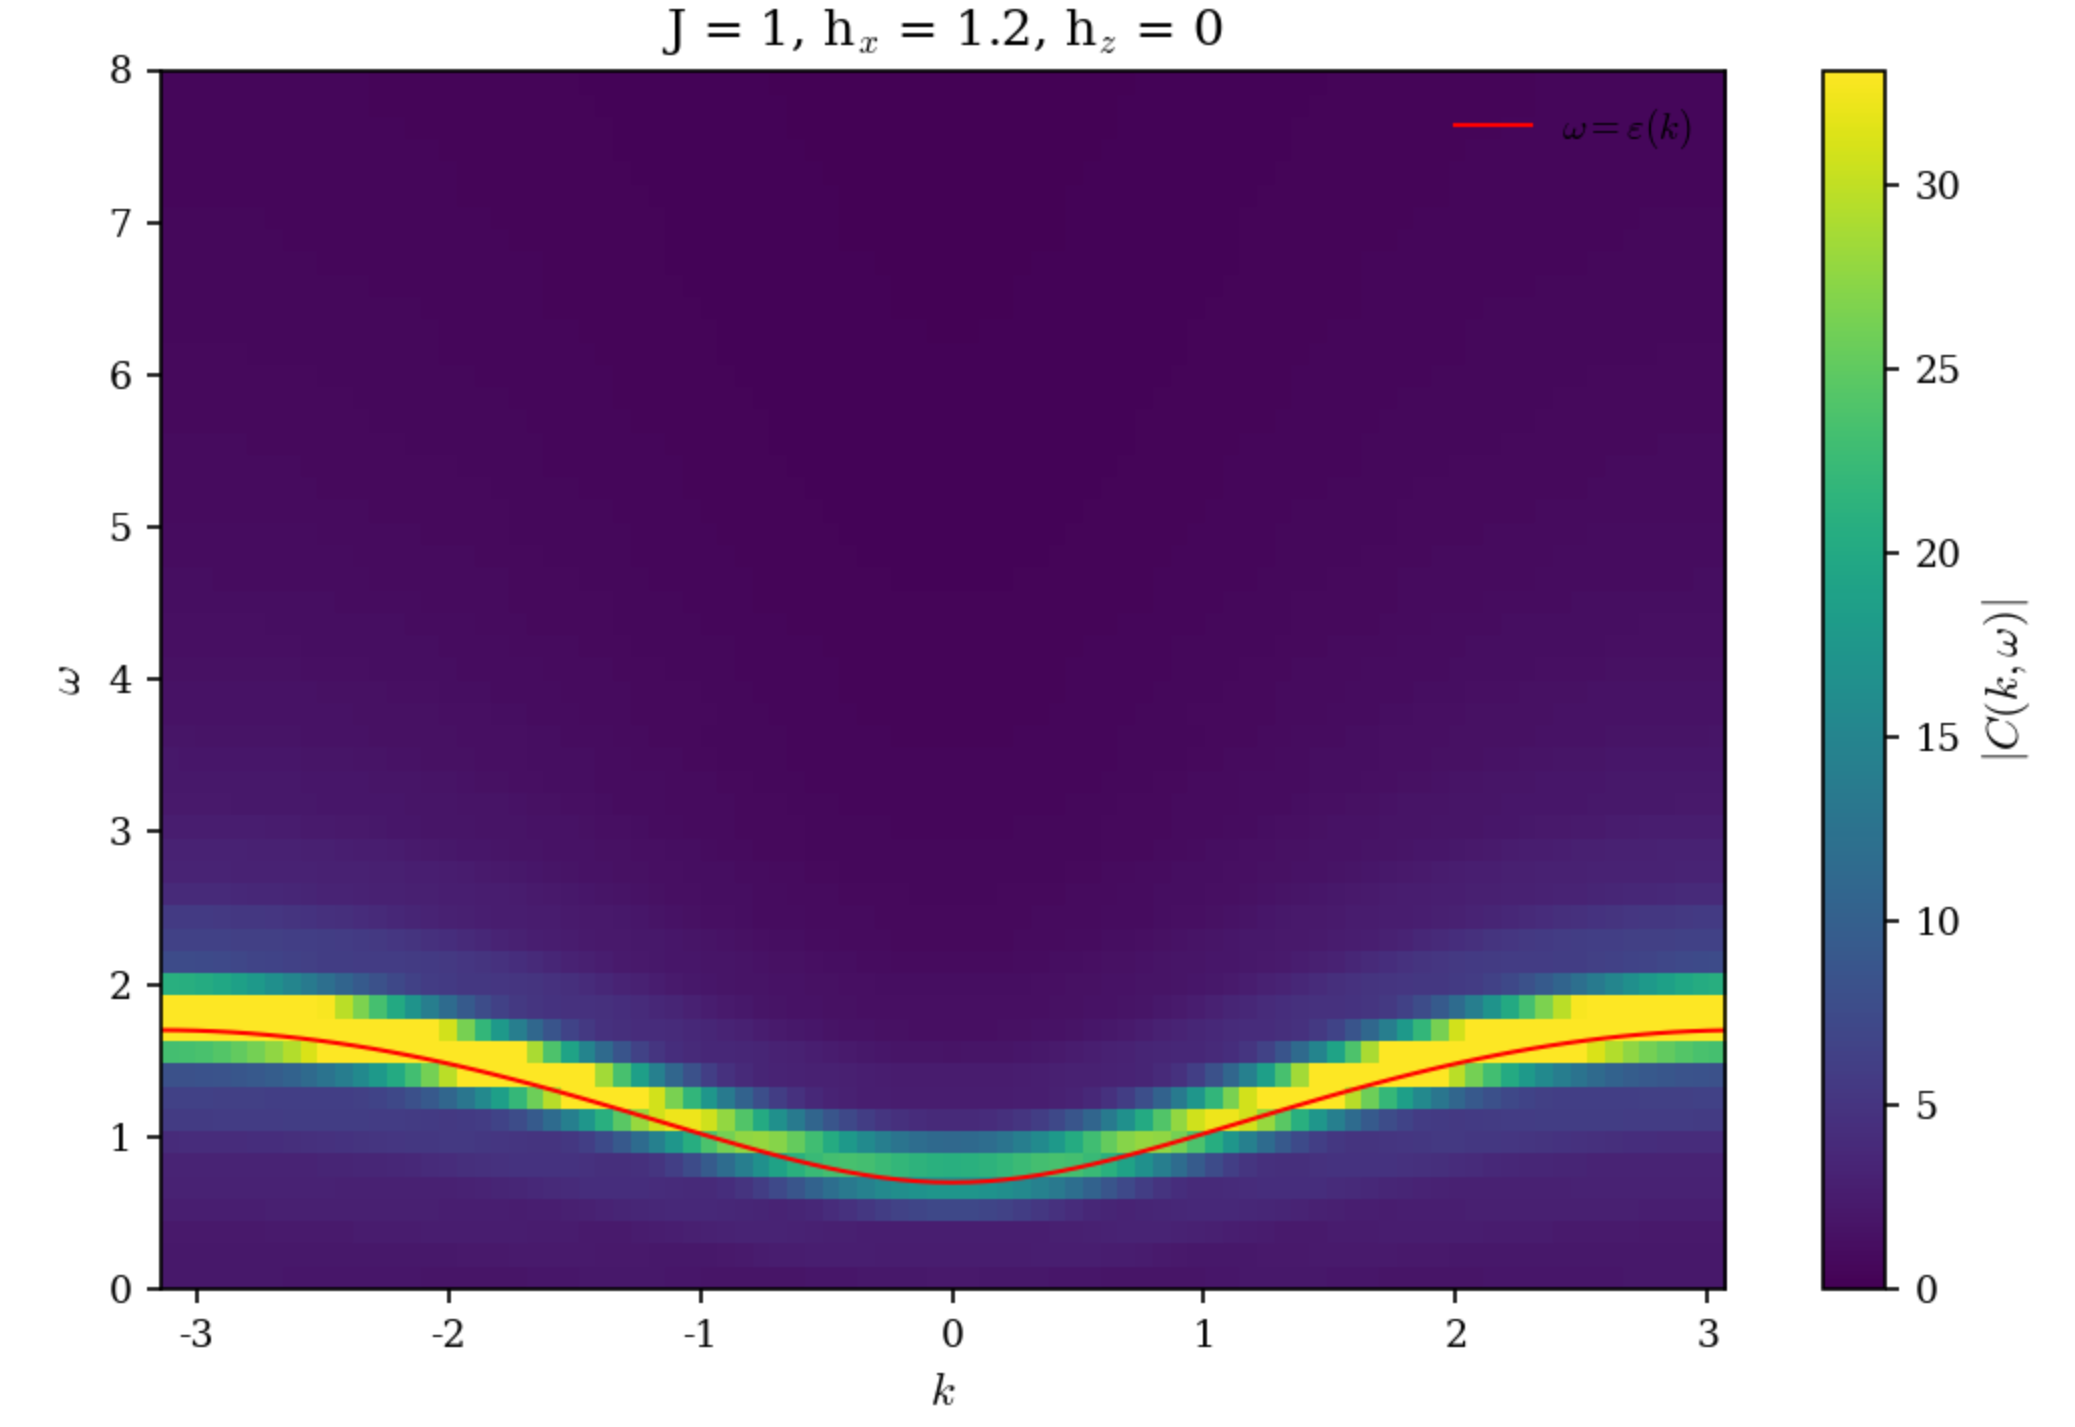

In [ ]:
# Convert datasets to .npz
def to_numpy32(t): 
    return t.detach().cpu().numpy().astype('float32')

# Exporting for Kaggle



np.savez_compressed(
    "Ctot_pack.npz",
    C_tot1=to_numpy32(C_tot1),
    C_tot2=to_numpy32(C_tot2),
    C_tot3=to_numpy32(C_tot3),
    C_tot4=to_numpy32(C_tot4),
    C_tot5=to_numpy32(C_tot5),
    C_tot6=to_numpy32(C_tot6),
    C_tot7=to_numpy32(C_tot7),
    C_tot8=to_numpy32(C_tot8),
    C_tot9=to_numpy32(C_tot9),
    C_tot10=to_numpy32(C_tot10),
    C_tot11=to_numpy32(C_tot11),
    C_tot12=to_numpy32(C_tot12),
    C_tot13=to_numpy32(C_tot13),
    C_tot14=to_numpy32(C_tot14),
    C_tot15=to_numpy32(C_tot15),
)

# Extracting the data on Kaggle

In this thesis I tested the TCN's ability to learn how to extrapolate the $<\sigma_y(\text{t})\sigma_{y,L/2}>$ correlator in k-space depending on which Ising chains we used for the training process. As you can see below, we performed multiple tests using different datasets created to explore different regimes of the Ising chain, for more details see my bachelor thesis.

In [ ]:
import numpy as np, torch, os
import matplotlib.pyplot as plt

print(os.listdir("/kaggle/input"))  # see your dataset slug
D = np.load("/kaggle/input/c-totxxx/Ctot_pack.npz")

C_tot1 = torch.from_numpy(D["C_tot1"]).T  # dtype float32
C_tot2 = torch.from_numpy(D["C_tot2"]).T
C_tot3 = torch.from_numpy(D["C_tot3"]).T
C_tot4 = torch.from_numpy(D["C_tot4"]).T
C_tot5 = torch.from_numpy(D["C_tot5"]).T
C_tot6 = torch.from_numpy(D["C_tot6"]).T  # dtype float32
C_tot7 = torch.from_numpy(D["C_tot7"]).T
C_tot8 = torch.from_numpy(D["C_tot8"]).T
C_tot9 = torch.from_numpy(D["C_tot9"]).T
C_tot10 = torch.from_numpy(D["C_tot10"]).T
C_tot11 = torch.from_numpy(D["C_tot11"]).T
C_tot12 = torch.from_numpy(D["C_tot12"]).T
C_tot13 = torch.from_numpy(D["C_tot13"]).T
C_tot14 = torch.from_numpy(D["C_tot14"]).T
C_tot15 = torch.from_numpy(D["C_tot15"]).T


# Last two Experiments
D = np.load("/kaggle/input/c-totxxx/Ctot_pack_V2.npz")
C_tot16 = torch.from_numpy(D["C_tot16"]).T  # dtype float32
C_tot17 = torch.from_numpy(D["C_tot17"]).T
C_tot18 = torch.from_numpy(D["C_tot18"]).T
C_tot19 = torch.from_numpy(D["C_tot19"]).T
C_tot20 = torch.from_numpy(D["C_tot20"]).T
C_tot21 = torch.from_numpy(D["C_tot21"]).T  # dtype float32
C_tot22 = torch.from_numpy(D["C_tot22"]).T
C_tot23 = torch.from_numpy(D["C_tot23"]).T

# Sanity checks (replace with your expected shapes)
for i, X in enumerate([C_tot1, C_tot2, C_tot3, C_tot4, C_tot5, C_tot6, C_tot7, C_tot8, C_tot9, C_tot10, C_tot11, C_tot12, C_tot13, C_tot14, C_tot15 ], 1):
    print(f"C_tot{i} shape:", tuple(X.shape), X.dtype)

import torch

def interleave_re_im(x: torch.Tensor) -> torch.Tensor:
    """
    x: (B, 180, T) where channels are concatenated as [Re1..Re90, Im1..Im90]
    returns: (B, 180, T) with channels interleaved [Re1, Im1, Re2, Im2, ...]
    """
    C, T = x.shape
    assert C % 2 == 0, f"Expected even channels, got {C}"  # Ensure even channels
    
    S = C // 2  # number of sites (90)

    # Split the tensor into real and imaginary parts
    re = x[:S, :]  # (B, 90, T) - real parts
    im = x[S:, :]  # (B, 90, T) - imaginary parts

    # Interleave them manually
    interleaved = torch.empty(C, T, dtype=x.dtype)
    interleaved[0::2, :] = re  # Place Re1, Re2, ..., Re90 in even slots
    interleaved[1::2, :] = im  # Place Im1, Im2, ..., Im90 in odd slots
    
    return interleaved


C_tot1 = interleave_re_im(C_tot1)
C_tot2 = interleave_re_im(C_tot2)
C_tot3 = interleave_re_im(C_tot3)
C_tot4 = interleave_re_im(C_tot4)
C_tot5 = interleave_re_im(C_tot5)
C_tot6= interleave_re_im(C_tot6)
C_tot7 = interleave_re_im(C_tot7)
C_tot8 = interleave_re_im(C_tot8)
C_tot9 = interleave_re_im(C_tot9)
C_tot10 = interleave_re_im(C_tot10)
C_tot11 = interleave_re_im(C_tot11)
C_tot12 = interleave_re_im(C_tot12)
C_tot13 = interleave_re_im(C_tot13)
C_tot14 = interleave_re_im(C_tot14)
C_tot15 = interleave_re_im(C_tot15)
C_tot16 = interleave_re_im(C_tot16)
C_tot17 = interleave_re_im(C_tot17)
C_tot18 = interleave_re_im(C_tot18)
C_tot19 = interleave_re_im(C_tot19)
C_tot20 = interleave_re_im(C_tot20)
C_tot21 = interleave_re_im(C_tot21)
C_tot22 = interleave_re_im(C_tot22)
C_tot23 = interleave_re_im(C_tot23)

for i, X in enumerate([C_tot1, C_tot2, C_tot3, C_tot4, C_tot5, C_tot6, C_tot7, C_tot8, C_tot9, C_tot10, C_tot11, C_tot12, C_tot13, C_tot14, C_tot15, C_tot16, C_tot17, C_tot18, C_tot19, C_tot20, C_tot21, C_tot22, C_tot23], 1):
    print(f"C_tot{i} shape:", tuple(X.shape), X.dtype)

# Define the TCN

In [ ]:
import torch.nn as nn 
from torch import nn, Tensor
import torch.nn.functional as F
from torch.autograd import Variable
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler
from torch.nn.utils.parametrizations import weight_norm

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
torch.backends.cudnn.benchmark = True  # small speed boost for convs

In [ ]:
import torch.nn as nn 
from torch import nn, Tensor
import torch.nn.functional as F
from torch.autograd import Variable
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler
from torch.nn.utils.parametrizations import weight_norm




class Chomp1d(nn.Module):
    def __init__(self, chomp_size):
        super(Chomp1d, self).__init__()
        self.chomp_size = chomp_size

    def forward(self, x):
        return x[:, :, :-self.chomp_size].contiguous()


class TemporalBlock(nn.Module):
    def __init__(self, n_inputs, n_outputs, kernel_size, stride, dilation, padding, dropout=0.1):
        super(TemporalBlock, self).__init__()
        self.conv1 = weight_norm(nn.Conv1d(n_inputs, n_outputs, kernel_size,
                                           stride=stride, padding=padding, dilation=dilation))
        self.chomp1 = Chomp1d(padding)
        self.relu1 = nn.ReLU()
        self.dropout1 = nn.Dropout(dropout)

        self.conv2 = weight_norm(nn.Conv1d(n_outputs, n_outputs, kernel_size,
                                           stride=stride, padding=padding, dilation=dilation))
        self.chomp2 = Chomp1d(padding)
        self.relu2 = nn.ReLU()
        self.dropout2 = nn.Dropout(dropout)

        self.net = nn.Sequential(self.conv1, self.chomp1, self.relu1, self.dropout1,
                                 self.conv2, self.chomp2, self.relu2, self.dropout2)
        self.downsample = nn.Conv1d(n_inputs, n_outputs, 1) if n_inputs != n_outputs else None
        self.relu = nn.ReLU()
        self.init_weights()

    def init_weights(self):
        self.conv1.weight.data.normal_(0, 0.01)
        self.conv2.weight.data.normal_(0, 0.01)
        if self.downsample is not None:
            self.downsample.weight.data.normal_(0, 0.01)

    def forward(self, x):
        out = self.net(x)
        res = x if self.downsample is None else self.downsample(x)
        return self.relu(out + res)


class TemporalConvNet(nn.Module):
    def __init__(self, num_inputs, num_channels, kernel_size, dropout=0.05):
        super(TemporalConvNet, self).__init__()
        layers = []
        num_levels = len(num_channels)
        for i in range(num_levels):
            dilation_size = 2 ** i
            in_channels = num_inputs if i == 0 else num_channels[i-1]
            out_channels = num_channels[i]
            layers += [TemporalBlock(in_channels, out_channels, kernel_size, stride=1, dilation=dilation_size,
                                     padding=(kernel_size-1) * dilation_size, dropout=dropout)]

        self.network = nn.Sequential(*layers)

    def forward(self, x):
        return self.network(x)


class TCN(nn.Module):
    def __init__(self, input_size, output_size, num_channels, kernel_size=10, dropout=0.05):
        super().__init__()
        self.tcn = TemporalConvNet(input_size, num_channels, kernel_size=kernel_size, dropout=dropout)
        self.linear = nn.Conv1d(num_channels[-1], output_size, kernel_size=1)  # Pointwise linear projection

    def forward(self, x):
        """
        x: (batch_size, input_size, seq_len)
        returns: (batch_size, output_size, seq_len)
        """
        y = self.tcn(x)           # (B, hidden_channels, T)
        out = self.linear(y)      # (B, output_size, T)
        return out


scaler = StandardScaler()



Until now, we separated the real and imaginary values of the correlation function for better structure, as such: 
(Re(C_1(t)), ..., Re(C_90(t)), Im(C_1(t)), ..., Im(C_90(t))).

But now we want the real and imaginary parts to be next to one another, as such: (Re(C_1(t)), Im(C_1(t)), Re(C_2(t)), Im(C_2(t)),...).

The following Code takes care of this and creates a large tensor containing all the datasets we want to use for training:

In [ ]:
seq_len = 60
target_len = 15
target_len_train = 45
num_2k = 90
X, Y = [], []

for k in range(0, num_2k):
    
    for start in range(0, 180 - seq_len - target_len_train + 1):
        
        x_seq = C_tot1[2*k:2*k+2, start: start + seq_len]           # Taking care of the first Dataset
        y_seq = C_tot1[2*k:2*k+2, start + seq_len: start+ seq_len + target_len_train]       
        X.append(x_seq)
        Y.append(y_seq)
    
        x_seq = C_tot2[2*k:2*k+2, start:start + seq_len]           # Taking care of the second Dataset
        y_seq = C_tot2[2*k:2*k+2, start + seq_len:start + seq_len + target_len_train]         
        X.append(x_seq)
        Y.append(y_seq)
    
        x_seq = C_tot3[2*k:2*k+2, start:start + seq_len]           # Taking care of the third Dataset
        y_seq = C_tot3[2*k:2*k+2, start + seq_len:start + seq_len + target_len_train]    
        X.append(x_seq)
        Y.append(y_seq)
        
        x_seq = C_tot4[2*k:2*k+2, start:start + seq_len]          # Taking care of the third Dataset
        y_seq = C_tot4[2*k:2*k+2, start + seq_len:start + seq_len + target_len_train]    
        X.append(x_seq)
        Y.append(y_seq)
        
        x_seq = C_tot5[2*k:2*k+2, start:start + seq_len]          # Taking care of the third Dataset
        y_seq = C_tot5[2*k:2*k+2, start + seq_len:start + seq_len + target_len_train]    
        X.append(x_seq)
        Y.append(y_seq)
        
        x_seq = C_tot6[2*k:2*k+2, start:start + seq_len]         # Taking care of the third Dataset
        y_seq = C_tot6[2*k:2*k+2, start + seq_len:start + seq_len + target_len_train]     
        X.append(x_seq)
        Y.append(y_seq)
        
        #x_seq = C_tot7[2*k:2*k+2, start:start + seq_len]            # Taking care of the third Dataset
        #y_seq = C_tot7[2*k:2*k+2, start + seq_len:start + seq_len + target_len_train]      
        #X.append(x_seq)
        #Y.append(y_seq)
        
        x_seq = C_tot8[2*k:2*k+2, start:start + seq_len]           # Taking care of the third Dataset
        y_seq = C_tot8[2*k:2*k+2, start + seq_len:start + seq_len + target_len_train]      
        X.append(x_seq)
        Y.append(y_seq)
        
        x_seq = C_tot9[2*k:2*k+2, start:start + seq_len]            # Taking care of the third Dataset
        y_seq = C_tot9[2*k:2*k+2, start + seq_len:start + seq_len + target_len_train]      
        X.append(x_seq)
        Y.append(y_seq)
        
        x_seq = C_tot10[2*k:2*k+2, start:start + seq_len]            # Taking care of the third Dataset
        y_seq = C_tot10[2*k:2*k+2, start + seq_len:start + seq_len + target_len_train]      
        X.append(x_seq)
        Y.append(y_seq)
        
        x_seq = C_tot11[2*k:2*k+2, start:start + seq_len]            # Taking care of the third Dataset
        y_seq = C_tot11[2*k:2*k+2, start + seq_len:start + seq_len + target_len_train]      
        X.append(x_seq)
        Y.append(y_seq)

        x_seq = C_tot12[2*k:2*k+2, start:start + seq_len]            # Taking care of the third Dataset
        y_seq = C_tot12[2*k:2*k+2, start + seq_len:start + seq_len + target_len_train]      
        X.append(x_seq)
        Y.append(y_seq)
        
        x_seq = C_tot13[2*k:2*k+2, start:start + seq_len]            # Taking care of the third Dataset
        y_seq = C_tot13[2*k:2*k+2, start + seq_len:start + seq_len + target_len_train]      
        X.append(x_seq)
        Y.append(y_seq)
        
        x_seq = C_tot14[2*k:2*k+2, start:start + seq_len]            # Taking care of the third Dataset
        y_seq = C_tot14[2*k:2*k+2, start + seq_len:start + seq_len + target_len_train]      
        X.append(x_seq)
        Y.append(y_seq)
        
        x_seq = C_tot15[2*k:2*k+2, start:start + seq_len]            # Taking care of the third Dataset
        y_seq = C_tot15[2*k:2*k+2, start + seq_len:start + seq_len + target_len_train]      
        X.append(x_seq)
        Y.append(y_seq)
        
        x_seq = C_tot16[2*k:2*k+2, start:start + seq_len]            # Taking care of the third Dataset
        y_seq = C_tot16[2*k:2*k+2, start + seq_len:start + seq_len + target_len_train]      
        X.append(x_seq)
        Y.append(y_seq)
        
        x_seq = C_tot17[2*k:2*k+2, start:start + seq_len]            # Taking care of the third Dataset
        y_seq = C_tot17[2*k:2*k+2, start + seq_len:start + seq_len + target_len_train]      
        X.append(x_seq)
        Y.append(y_seq)
        
        x_seq = C_tot18[2*k:2*k+2, start:start + seq_len]            # Taking care of the third Dataset
        y_seq = C_tot18[2*k:2*k+2, start + seq_len:start + seq_len + target_len_train]      
        X.append(x_seq)
        Y.append(y_seq)
        
        x_seq = C_tot19[2*k:2*k+2, start:start + seq_len]            # Taking care of the third Dataset
        y_seq = C_tot19[2*k:2*k+2, start + seq_len:start + seq_len + target_len_train]      
        X.append(x_seq)
        Y.append(y_seq)
        
        #x_seq = C_tot20[2*k:2*k+2, start:start + seq_len]            # Taking care of the third Dataset
        #y_seq = C_tot20[2*k:2*k+2, start + seq_len:start + seq_len + target_len_train]      
        #X.append(x_seq)
        #Y.append(y_seq)
        
        #x_seq = C_tot21[2*k:2*k+2, start:start + seq_len]            # Taking care of the third Dataset
        #y_seq = C_tot21[2*k:2*k+2, start + seq_len:start + seq_len + target_len_train]      
        #X.append(x_seq)
        #Y.append(y_seq)
        
        #x_seq = C_tot22[2*k:2*k+2, start:start + seq_len]            # Taking care of the third Dataset
        #y_seq = C_tot22[2*k:2*k+2, start + seq_len:start + seq_len + target_len_train]      
        #X.append(x_seq)
        #Y.append(y_seq)
        
        #x_seq = C_tot23[2*k:2*k+2, start:start + seq_len]            # Taking care of the third Dataset
        #y_seq = C_tot23[2*k:2*k+2, start + seq_len:start + seq_len + target_len_train]      
        #X.append(x_seq)
        #Y.append(y_seq)
        

X_tensor = torch.stack([x.detach().clone() for x in X])  # (samples, features, seq_len)
Y_tensor = torch.stack([y.detach().clone() for y in Y])  # (samples, features, target_len)

X_train, X_val, Y_train, Y_val = train_test_split(X_tensor, Y_tensor, test_size=0.2, random_state=42)

X_train = torch.stack([x.detach().clone() for x in X_train])
Y_train = torch.stack([y.detach().clone() for y in Y_train])

X_val = torch.stack([x.detach().clone() for x in X_val])
Y_val = torch.stack([y.detach().clone() for y in Y_val])

train_dataset = TensorDataset(X_train, Y_train)
val_dataset = TensorDataset(X_val, Y_val)

train_loader = DataLoader(train_dataset, batch_size=50, shuffle=True, pin_memory=torch.cuda.is_available(), num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=50, shuffle=False, pin_memory=torch.cuda.is_available(), num_workers=2)


In [ ]:
# Now we define the parameters of the TCN (four convolutional layers, kernel size 7, ...)


model = TCN(input_size=2, output_size=2, num_channels=[64, 64, 64, 128], kernel_size=7, dropout=0.05)
model = model.to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
#scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode = "min", factor = 0.1, patience = 10, min_lr=1e-6)
loss_fn = nn.MSELoss()
loss_fn = nn.MSELoss().to(device)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=80, eta_min=1e-8)


model.train()
losss = []

best_val_loss = float('inf')
epochs_without_improvement = 0
patience = 5  # How many epochs to wait before stopping if no improvement
best_model_state = None

# Enable gradient tracking
model.train()
losss = []


for epoch in range(80):  # Replace with `max_epochs` if you prefer
    epoch_loss = 0.0
    model.train()
    for x_batch, y_batch in train_loader:  # Train DataLoader
        x_batch = x_batch.to(device, non_blocking=True)
        y_batch = y_batch.to(device, non_blocking=True)
        
        optimizer.zero_grad()
        
        # Rollout for predicting future steps (unchanged)
        output = model(x_batch)               # (B, features, seq_len)
        output = output[:, :, -target_len:]   # Get the last `target_len` time steps

        for _ in range(1, target_len_train // target_len):  # Repeat until we reach the full target_len_train
            x_batch = torch.cat([x_batch[:, :, target_len:], output], dim=2)  # Shift by target_len steps
            future_output = model(x_batch)
            future_output = future_output[:, :, -target_len:]  # Keep only the last `target_len` predictions
            output = torch.cat([output, future_output], dim=2)  # Append to predictions
        
        # Calculate loss
        loss = loss_fn(output, y_batch)
        loss.backward()
        optimizer.step()
        
        epoch_loss += loss.item()
    
    losss.append(epoch_loss)
    
    # Validation Phase
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for x_batch, y_batch in val_loader:  # Validation DataLoader
            x_batch = x_batch.to(device, non_blocking=True)
            y_batch = y_batch.to(device, non_blocking=True)

            output = model(x_batch)               # (B, features, seq_len)
            output = output[:, :, -target_len:]
            
            for _ in range(1, target_len_train // target_len):  # Repeat until we reach the full target_len_train
                x_batch = torch.cat([x_batch[:, :, target_len:], output], dim=2)  # Shift by target_len steps
                future_output = model(x_batch)
                future_output = future_output[:, :, -target_len:]  # Keep only the last `target_len` predictions
                output = torch.cat([output, future_output], dim=2)  # Append to predictions
           
            
            val_loss += loss_fn(output, y_batch[:, :, :]).item()
    
    val_loss /= len(val_loader)  # Average validation loss over the validation set
    
    print(f"Epoch {epoch+1}, Train Loss: {epoch_loss:.4f}, Validation Loss: {val_loss:.6g}")
    
    # Early stopping check
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_model_state = model.state_dict()  # Save the best model state
        epochs_without_improvement = 0
    else:
        epochs_without_improvement += 1
    
    # If no improvement for 'patience' epochs, stop training
    if epochs_without_improvement >= patience:
        print(f"Early stopping triggered at epoch {epoch+1} due to no improvement.")
        break

    # Optional: If using a learning rate scheduler
    scheduler.step()

# After training finishes (or early stopping)
if best_model_state:
    model.load_state_dict(best_model_state)  # Load the best model state
    print("Loaded the best model state.")

# Save the final model checkpoint after training
torch.save(model.state_dict(), 'final_model_checkpoint.pth')


# Plotting the loss function as well as one output as a sanity check
plt.plot(losss)
plt.yscale('log')
plt.show()
plt.plot(output[0, 0, :].detach().cpu().numpy(), label = "TCN")
plt.plot(y_batch[0,0,:].detach().cpu(), label = "Pure")
plt.legend()
plt.show()

# Testing our model on unseen data

In [ ]:
Final_Prediction_TCN1 = []

# So first we'll create a copy of our model, then we'll pretrain it
model_1 = copy.deepcopy(model).to(device)

# Now comes the batch
X, Y = [], []
for k in range(0, num_2k):
    
    for start in range(0, 120 - seq_len - target_len_train + 1):
    
        x_seq = C_tot1[2*k:2*k + 2, start: start + seq_len]          # Taking care of the first Dataset
        y_seq = C_tot1[2*k:2*k + 2, start + seq_len: start+ seq_len + target_len_train]       
        X.append(x_seq)
        Y.append(y_seq)

X_tensor = torch.stack([x.detach().clone() for x in X])  # (samples, features, seq_len)
Y_tensor = torch.stack([y.detach().clone() for y in Y])  # (samples, features, target_len)

X_train, X_val, Y_train, Y_val = train_test_split(X_tensor, Y_tensor, test_size=0.2, random_state=42)

X_train = torch.stack([x.detach().clone() for x in X_train])
Y_train = torch.stack([y.detach().clone() for y in Y_train])

X_val = torch.stack([x.detach().clone() for x in X_val])
Y_val = torch.stack([y.detach().clone() for y in Y_val])

train_dataset = TensorDataset(X_train, Y_train)
val_dataset = TensorDataset(X_val, Y_val)

train_loader = DataLoader(train_dataset, batch_size=50, shuffle=True, pin_memory=torch.cuda.is_available(), num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=50, shuffle=False, pin_memory=torch.cuda.is_available(), num_workers=2)

loss_fn = nn.L1Loss()
loss_fn = nn.L1Loss().to(device)
optimizer = torch.optim.Adam(model_1.parameters(), lr=1e-7)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=80, eta_min=1e-13)

best_val_loss = float('inf')
epochs_without_improvement = 0
patience = 5  # How many epochs to wait before stopping if no improvement
best_model_state = None

model_1.train()

losss1 = []
for epoch in range(80):  # Replace with `max_epochs` if you prefer
    model_1.train()
    epoch_loss = 0.0
    for x_batch, y_batch in train_loader:  # Train DataLoader
        x_batch = x_batch.to(device, non_blocking=True)
        y_batch = y_batch.to(device, non_blocking=True)
        
        optimizer.zero_grad()
        
        # Rollout for predicting future steps (unchanged)
        output = model_1(x_batch)               # (B, features, seq_len)
        output = output[:, :, -target_len:]   # Get the last `target_len` time steps

        for _ in range(1, target_len_train // target_len):  # Repeat until we reach the full target_len_train
            x_batch = torch.cat([x_batch[:, :, target_len:], output], dim=2)  # Shift by target_len steps
            future_output = model_1(x_batch)
            future_output = future_output[:, :, -target_len:]  # Keep only the last `target_len` predictions
            output = torch.cat([output, future_output], dim=2)  # Append to predictions
        
        # Calculate loss
        loss = loss_fn(output, y_batch)
        loss.backward()
        optimizer.step()
        
        epoch_loss += loss.item()
    
    losss1.append(epoch_loss)
    
    # Validation Phase
    model_1.eval()
    val_loss = 0.0
    with torch.no_grad():
        for x_batch, y_batch in val_loader:  # Validation DataLoader
            x_batch = x_batch.to(device, non_blocking=True)
            y_batch = y_batch.to(device, non_blocking=True)

            output = model_1(x_batch)               # (B, features, seq_len)
            output = output[:, :, -target_len:]
            
            for _ in range(1, target_len_train // target_len):  # Repeat until we reach the full target_len_train
                x_batch = torch.cat([x_batch[:, :, target_len:], output], dim=2)  # Shift by target_len steps
                future_output = model_1(x_batch)
                future_output = future_output[:, :, -target_len:]  # Keep only the last `target_len` predictions
                output = torch.cat([output, future_output], dim=2)  # Append to predictions
           
            
            val_loss += loss_fn(output, y_batch[:, :, :]).item()
    
    val_loss /= len(val_loader)  # Average validation loss over the validation set
    
    print(f"Epoch {epoch+1}, Train Loss: {epoch_loss:.4f}, Validation Loss: {val_loss:.6g}")
    
    # Early stopping check
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_model_state = model_1.state_dict()  # Save the best model state
        epochs_without_improvement = 0
    else:
        epochs_without_improvement += 1
    
    # If no improvement for 'patience' epochs, stop training
    if epochs_without_improvement >= patience:
        print(f"Early stopping triggered at epoch {epoch+1} due to no improvement.")
        break

    # Optional: If using a learning rate scheduler
    scheduler.step()

# After training finishes (or early stopping)
if best_model_state:
    model_1.load_state_dict(best_model_state)  # Load the best model state
    print("Loaded the best model state.")

# Save the final model checkpoint after training
torch.save(model_1.state_dict(), 'final_model_checkpoint.pth')

model_1.eval()
C_tot1 = C_tot1.to(device)

with torch.no_grad():
    
    
    for k in range(0, num_2k):
        C_start = C_tot1[2*k:2*k + 2, 0:120].detach().clone().unsqueeze(0)  #(features, 150)
        for i in range(4):  
            input_1 = C_start[:, :, -seq_len:]  #(1, features, 100)
            pred = model_1(input_1)# (1, features, 20)
            pred = pred[:, :, -target_len:] # (1, features, 10)
            #pred = pred.squeeze(0)                               #(features, 20)

        
            C_start = torch.cat((C_start, pred), dim=2)
        
        Final_Prediction_TCN1.append(C_start.squeeze(0))

Final_Prediction_TCN1 = torch.cat(Final_Prediction_TCN1, dim=0) 
Final_Prediction_TCN1 = Final_Prediction_TCN1.detach().cpu().numpy()



x1 = 0.1*np.arange(180)
x2 = 0.1*np.arange(181)



plt.figure()
plt.plot(losss1)
plt.yscale('log')
plt.title("Loss function DS1")
plt.show()

plt.figure()
plt.plot(Final_Prediction_TCN1[13,:], label = "TCN")
plt.plot(C_tot1.detach().cpu().numpy()[13, :], label = "Ground Truth")
plt.title("J = 1, h = 0.3, g = 0, k = 13")
plt.legend()
plt.show()

# Results

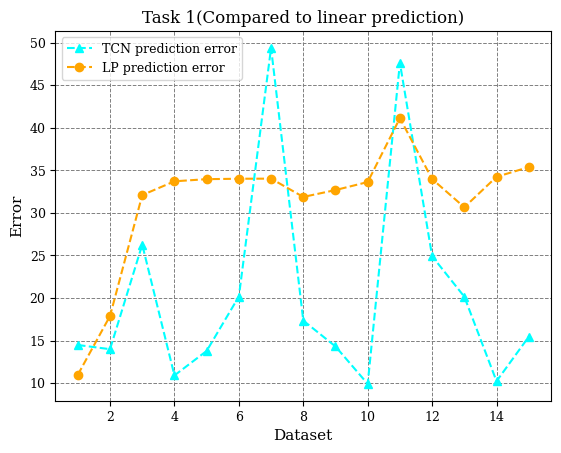

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

# --- minimal font/style tweak to match LaTeX serif ---
mpl.rcParams.update({
    "font.family": "serif",
    "font.serif": ["CMU Serif", "Computer Modern Roman", "DejaVu Serif"],
    "mathtext.fontset": "cm",
    "axes.unicode_minus": False,
    "font.size": 10,        # body
    "axes.labelsize": 11,   # axis labels
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 9,
})

TcN = (14.487, 13.993, 26.273, 10.913, 13.786, 20.180, 49.381, 17.355, 14.315, 9.914, 47.628, 24.916, 20.159, 10.235, 15.447)
Lp = (10.987, 17.895, 32.096, 33.714, 33.966, 34.015, 34.026, 31.877, 32.686, 33.626, 41.135, 33.977, 30.665, 34.240, 35.378)

DS = (1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15)

plt.plot(DS, TcN, marker='^', markersize=6, linestyle='--', color='cyan', label = "TCN prediction error")
plt.plot(DS, Lp, marker='o', markersize=6, linestyle='--', color='orange', label = "LP prediction error")
plt.grid(True, which='both', axis='both', color='gray', linestyle='--', linewidth=0.7)
plt.legend()
plt.xlabel("Dataset")
plt.ylabel("Error")
plt.title("Task 1(Compared to linear prediction)")
plt.show()

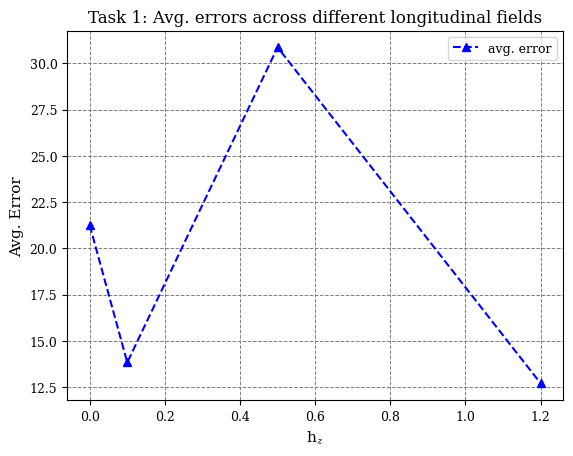

In [3]:
import numpy as np
import matplotlib.pyplot as plt



hz = (0,0.1,0.5, 1.2)
E = (21.25, 13.83, 30.87, 12.7)


plt.plot(hz, E, marker='^', markersize=6, linestyle='--', color='b', label = "avg. error")
plt.grid(True, which='both', axis='both', color='gray', linestyle='--', linewidth=0.7)
plt.legend()
plt.xlabel("h$_z$")
plt.ylabel("Avg. Error")
plt.title("Task 1: Avg. errors across different longitudinal fields")
plt.show()

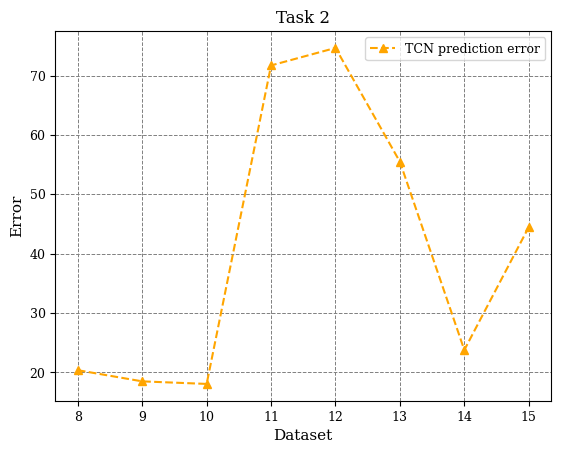

In [2]:
import numpy as np
import matplotlib.pyplot as plt

E = (20.359, 18.479, 18.048, 71.699, 74.649, 55.472, 23.764, 44.458)
DS = (8, 9, 10, 11, 12, 13, 14, 15)

plt.plot(DS, E, marker='^', markersize=6, linestyle='--', color='orange', label = "TCN prediction error")
plt.grid(True, which='both', axis='both', color='gray', linestyle='--', linewidth=0.7)
plt.legend()
plt.xlabel("Dataset")
plt.ylabel("Error")
plt.title("Task 2")
plt.show()

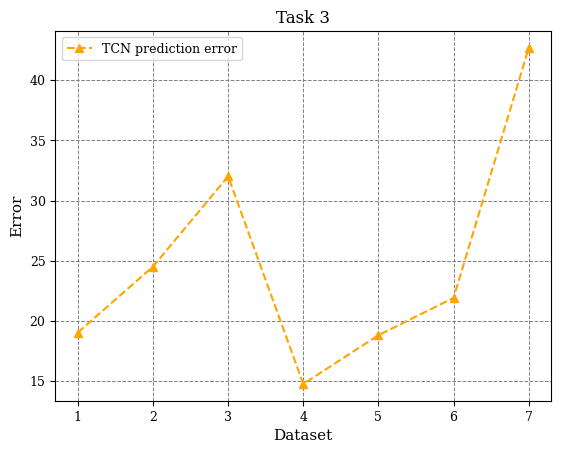

In [4]:
import numpy as np
import matplotlib.pyplot as plt

E = (19.031, 24.510, 32.007, 14.760, 18.807, 21.913, 42.683) 
DS = (1, 2, 3, 4, 5, 6, 7)

plt.plot(DS, E, marker='^', markersize=6, linestyle='--', color='orange', label = "TCN prediction error")
plt.grid(True, which='both', axis='both', color='gray', linestyle='--', linewidth=0.7)
plt.legend()
plt.xlabel("Dataset")
plt.ylabel("Error")
plt.title("Task 3")
plt.show()

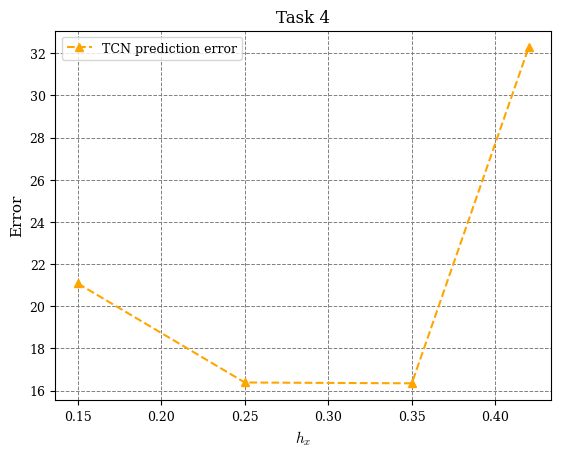

In [5]:
import numpy as np
import matplotlib.pyplot as plt

# experiment 4:
# error 16 = 21.081535
# error 17 = 16.384544
# error 18 = 16.345425
# error 19 = 32.28011

E = (21.081535, 16.384544, 16.345425, 32.28011)
DS = (0.15, 0.25, 0.35, 0.42)

plt.plot(DS, E, marker='^', markersize=6, linestyle='--', color='orange', label = "TCN prediction error")
plt.grid(True, which='both', axis='both', color='gray', linestyle='--', linewidth=0.7)
plt.legend()
plt.xlabel(r"$h_x$")
plt.ylabel("Error")
plt.title("Task 4")
plt.show()

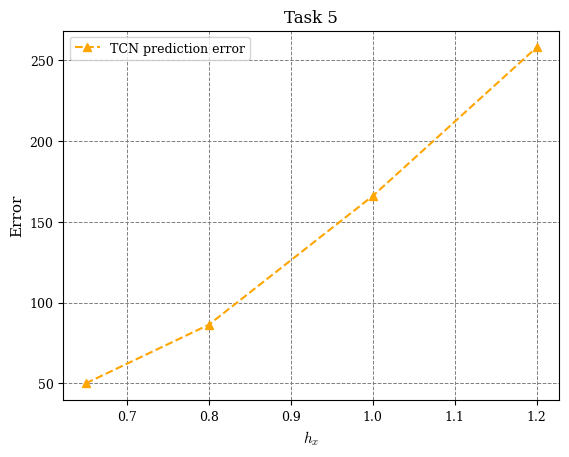

In [6]:
import numpy as np
import matplotlib.pyplot as plt

# experiment 5:
# error 20 = 50.029785
# error 21 = 86.291214
# error 22 = 165.974
# error 23 = 257.93555

E = (50.029785, 86.291214, 165.974, 257.93555)
DS = (0.65, 0.8, 1, 1.2)

plt.plot(DS, E, marker='^', markersize=6, linestyle='--', color='orange', label = "TCN prediction error")
plt.grid(True, which='both', axis='both', color='gray', linestyle='--', linewidth=0.7)
plt.legend()
plt.xlabel(r"$h_x$")
plt.ylabel("Error")
plt.title("Task 5")
plt.show()

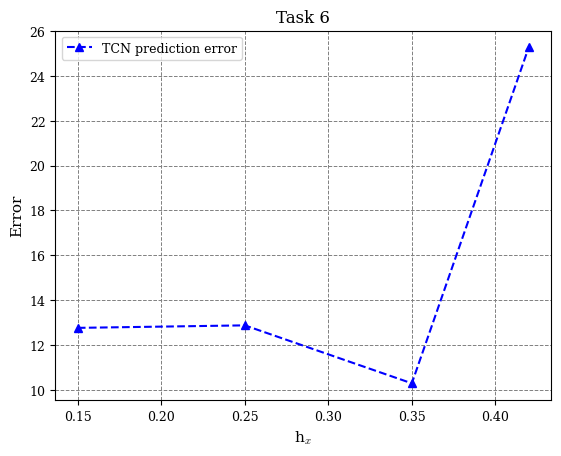

In [7]:
import numpy as np
import matplotlib.pyplot as plt

# experiment 6:
# error 16 = 12.405651
# error 17 = 15.291536
# error 18 = 10.286478
# error 19 = 25.27903

hx1 = (0.15,0.25,0.35, 0.42)
E1 = (12.761, 12.8728075, 10.286478, 25.27903)




plt.plot(hx1, E1, marker='^', markersize=6, linestyle='--', color='b', label = "TCN prediction error")
plt.grid(True, which='both', axis='both', color='gray', linestyle='--', linewidth=0.7)
plt.legend()
plt.xlabel("h$_x$")
plt.ylabel("Error")
plt.title("Task 6")
plt.show()

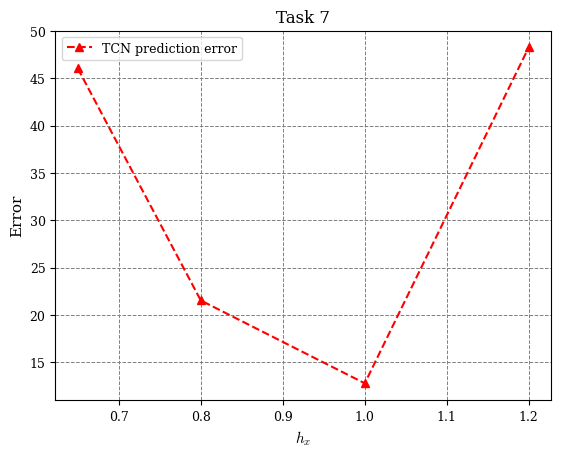

In [8]:
import numpy as np
import matplotlib.pyplot as plt

# experiment 7:
# error 20 = 46.023376
# error 21 = 21.538801
# error 22 = 12.792522
# error 23 = 48.257988

hx2 = (0.65, 0.8, 1, 1.2)
E2 = (46.023376, 21.538801, 12.792522, 48.257988)

plt.plot(hx2, E2, marker='^', markersize=6, linestyle='--', color='r', label = "TCN prediction error")
plt.grid(True, which='both', axis='both', color='gray', linestyle='--', linewidth=0.7)
plt.legend()
plt.xlabel(r"$h_x$")
plt.ylabel("Error")
plt.title("Task 7")
plt.show()

# Dynamic spin factor (When TCN was able to pick up on the patterns)

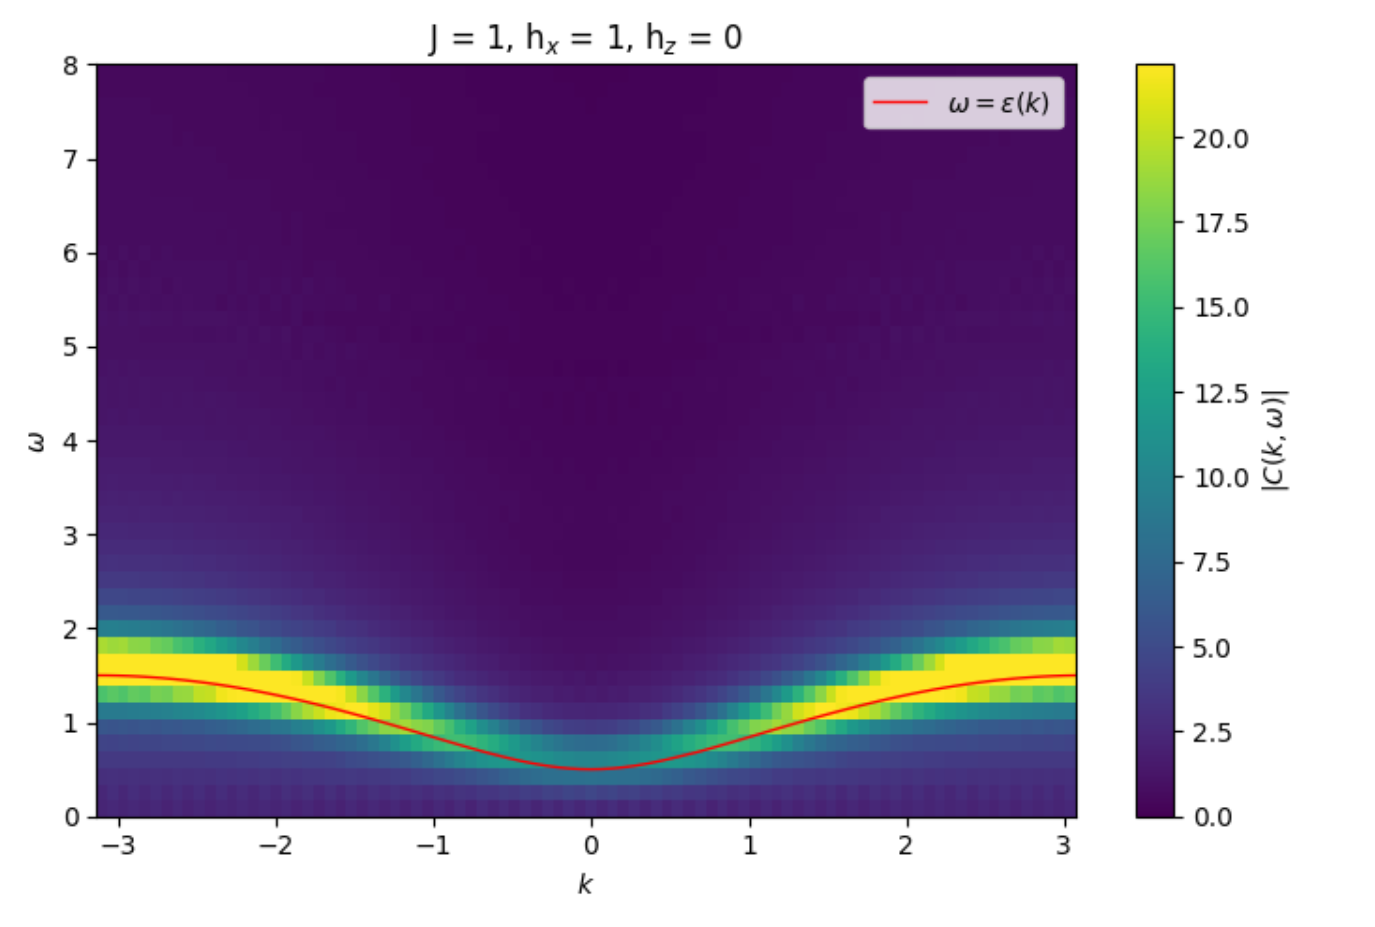

# Dynamic spin factor (When TCN was not able to pick up on the patterns)

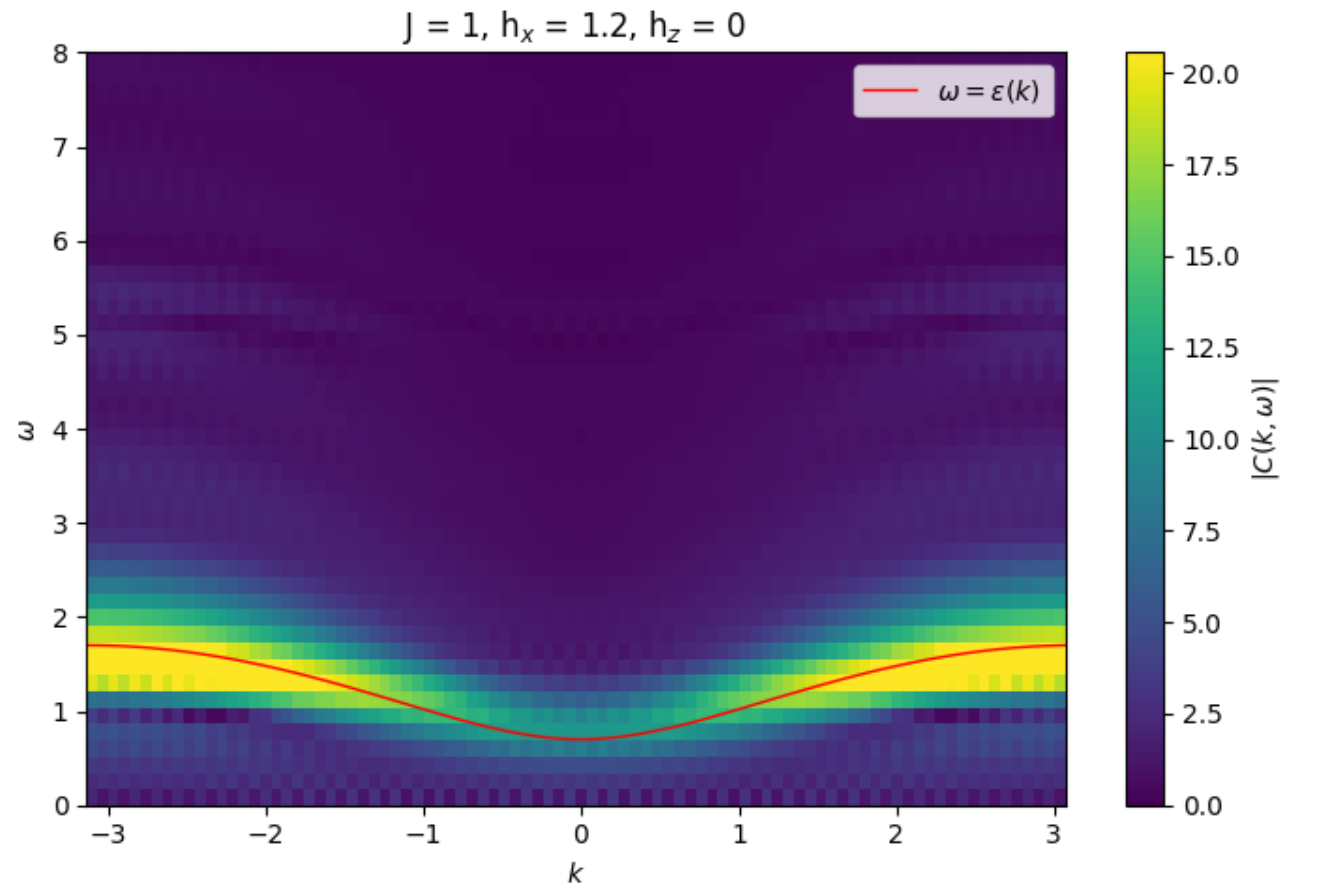